In [189]:
import pandas as pd
import numpy as nm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [190]:
df = pd.read_csv("/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv")

In [191]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [192]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [194]:
df.shape

(1000, 9)

In [195]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [196]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [197]:
df.nunique()

Transaction ID      1000
Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
dtype: int64

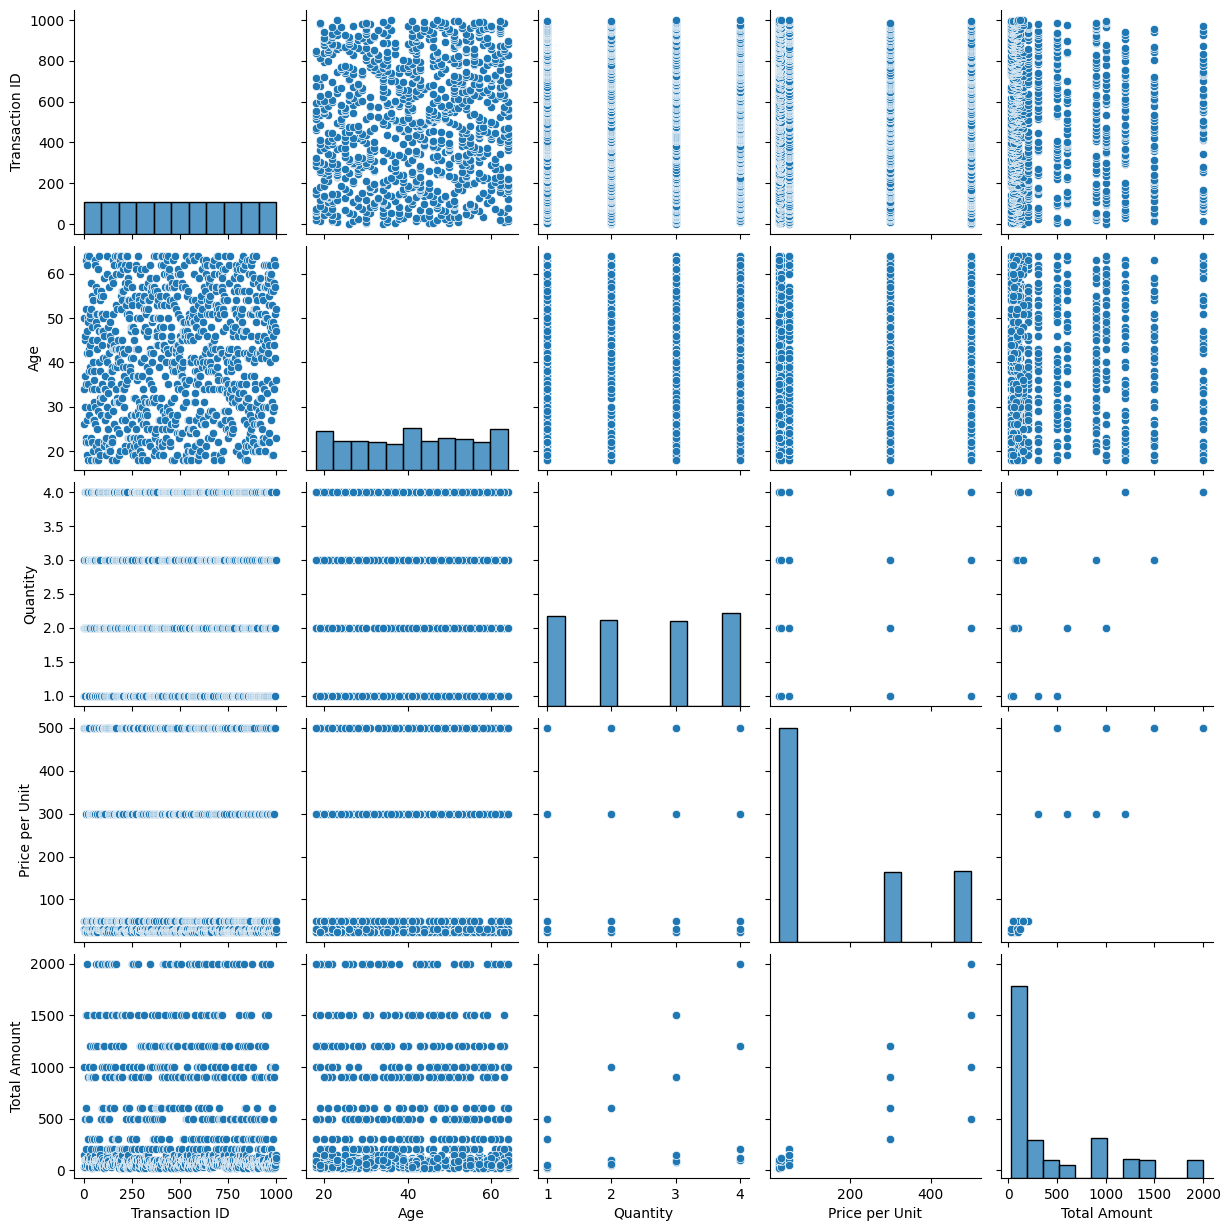

In [198]:
sns.pairplot(df)

In [199]:
df[df['Product Category'].isin(['Clothing','Beauty','Electronics'])]['Product Category'].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

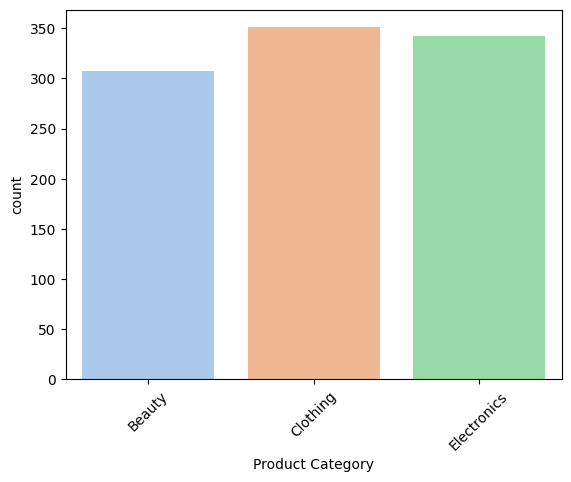

In [200]:
sns.countplot(x=df['Product Category'], palette = 'pastel')
plt.xticks(rotation=45)
plt.show()

In [201]:
df.groupby("Product Category")[['Quantity','Total Amount']].sum()

,Quantity,Total Amount
Product Category,,
Beauty,771,143515
Clothing,894,155580
Electronics,849,156905


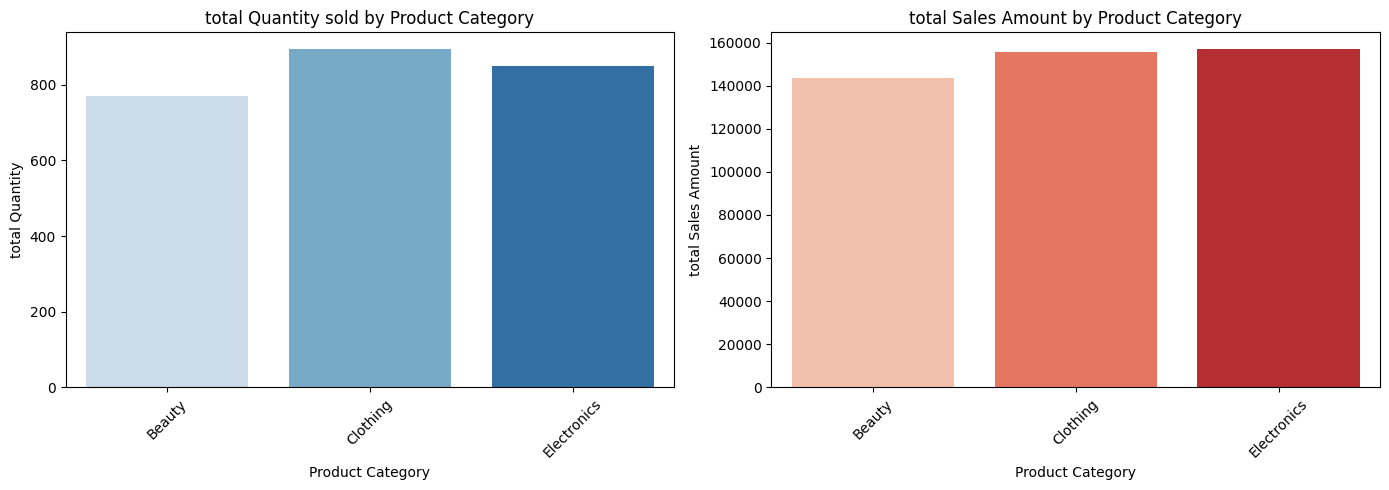

In [202]:
Category_summary = df.groupby("Product Category")[['Quantity','Total Amount']].sum()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# For Quantity
sns.barplot(x=Category_summary.index, y=Category_summary['Quantity'], ax=ax[0], palette='Blues')
ax[0].set_title("total Quantity sold by Product Category")
ax[0].set_xlabel("Product Category")
ax[0].set_ylabel("total Quantity")
ax[0].tick_params(axis='x', rotation=45)

# For Total Amount
sns.barplot(x=Category_summary.index, y=Category_summary['Total Amount'], ax=ax[1], palette='Reds')
ax[1].set_title("total Sales Amount by Product Category")
ax[1].set_xlabel("Product Category")
ax[1].set_ylabel("total Sales Amount")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

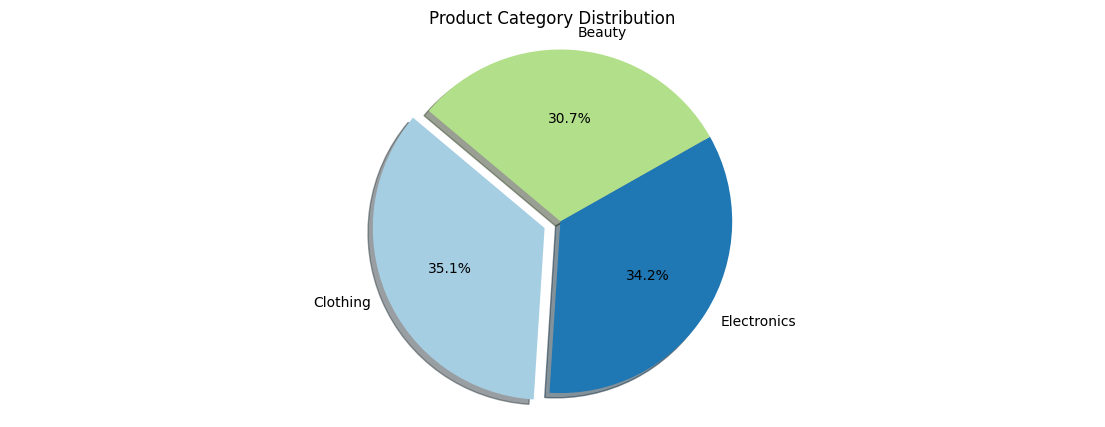

In [203]:
Category_counts = df["Product Category"].value_counts()

explode_list = [0.1 if i == Category_counts.idxmax() else 0 for i in Category_counts.index]

#pie chart
plt.figure(figsize=(14,5))
plt.pie(
    Category_counts,
    labels = Category_counts.index,
    autopct = "%1.1f%%",
    colors = plt.cm.Paired.colors,
    explode = explode_list,
    startangle = 140,
    shadow = True
)

plt.title("Product Category Distribution")
plt.axis('equal')
plt.show

In [204]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date']

df['Month'] = df['Date'].dt.month_name()
df['Month']

0      November
1      February
2       January
3           May
4           May
         ...   
995         May
996    November
997     October
998    December
999       April
Name: Month, Length: 1000, dtype: object

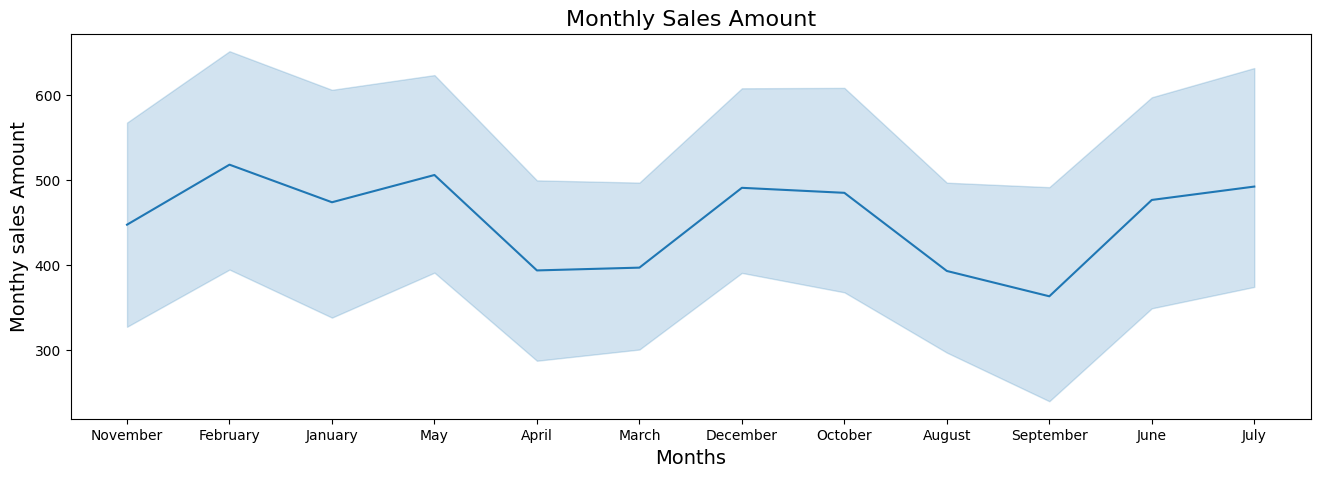

In [205]:
plt.figure(figsize=(16,5))
sns.lineplot(x='Month', y='Total Amount', data= df)
plt.title("Monthly Sales Amount", fontsize=16)
plt.xlabel('Months', fontsize=14)
plt.ylabel('Monthy sales Amount', fontsize=14)
plt.show()

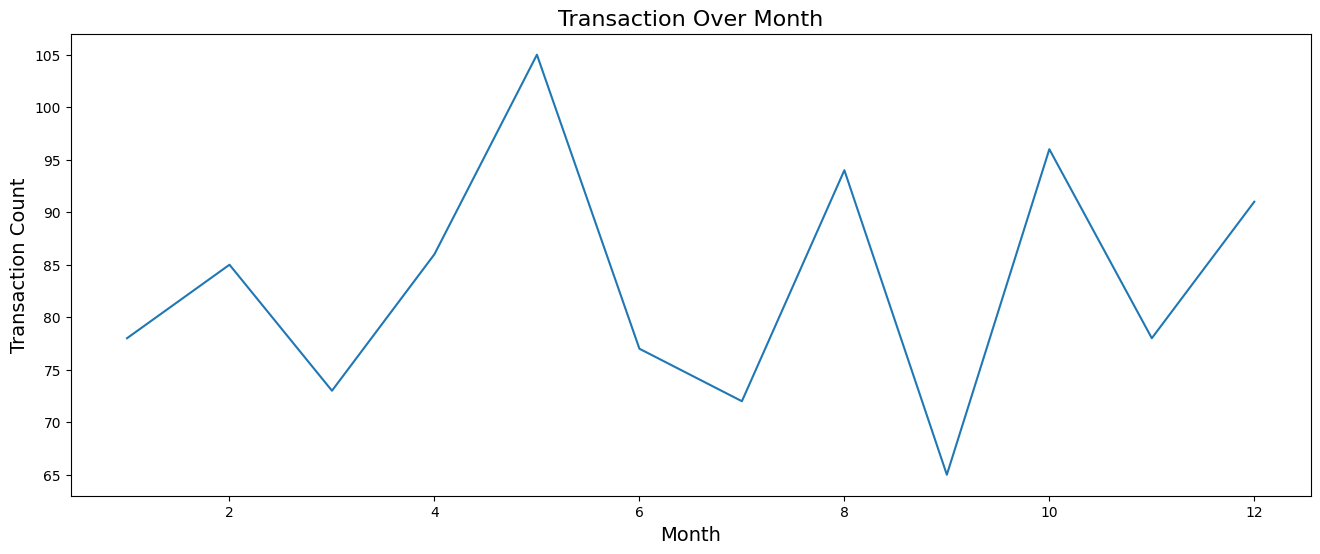

In [206]:
df['Month'] = df['Date'].dt.month
transaction_count = df.groupby('Month')['Transaction ID'].count()

plt.figure(figsize=(16,6))
sns.lineplot( x = transaction_count.index, y = transaction_count.values)
plt.title('Transaction Over Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Transaction Count', fontsize=14)
plt.show()

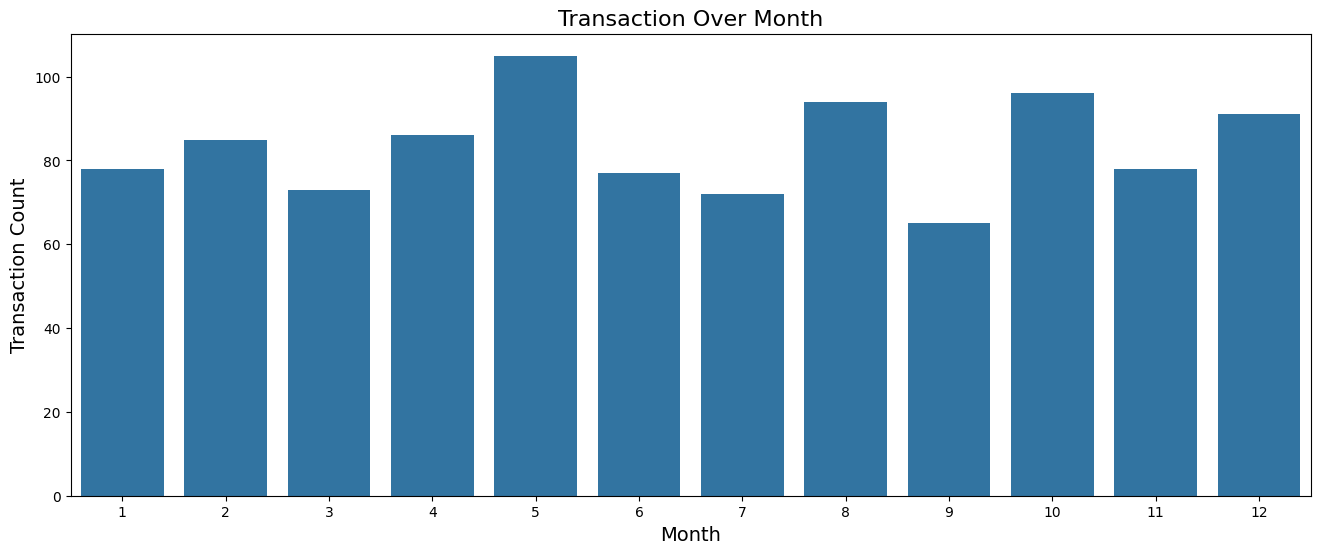

In [207]:
df['Month'] = df['Date'].dt.month
transaction_count = df.groupby('Month')['Transaction ID'].count()

plt.figure(figsize=(16,6))
sns.barplot( x = transaction_count.index, y = transaction_count.values)
plt.title('Transaction Over Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Transaction Count', fontsize=14)
plt.show()

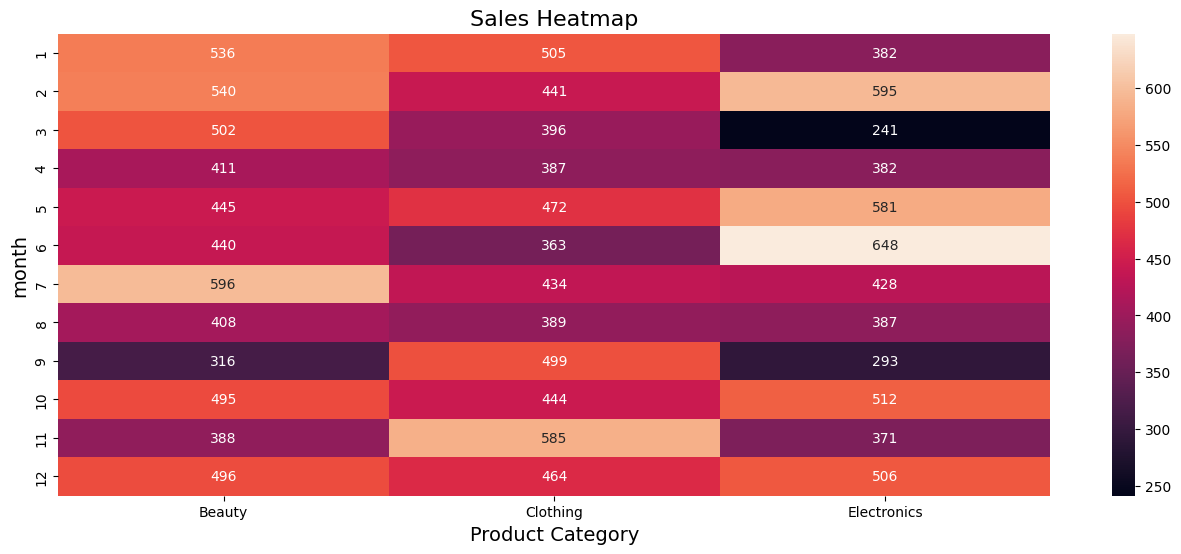

In [208]:
heatmap = df.pivot_table(index='Month', columns='Product Category', values='Total Amount')
plt.figure(figsize=(16,6))
sns.heatmap(heatmap, annot= True , fmt='.0f')
plt.title('Sales Heatmap', fontsize='16')
plt.xlabel('Product Category', fontsize='14')
plt.ylabel('month', fontsize='14')
plt.show()


In [209]:
df['Age'].count()

np.int64(1000)

In [210]:
df[df['Gender'].isin(['Male', 'Female'])]['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

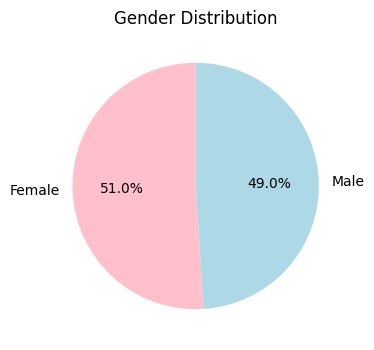

In [211]:
gender_counts= {'Female': 510, 'Male':490}

plt.figure(figsize=(6,4))
plt.pie(gender_counts.values(), labels=gender_counts.keys(), autopct='%1.1f%%', colors=['pink','lightblue'], startangle= 90)
plt.title('Gender Distribution')
plt.show()

In [212]:
age_bins = [0,18,25,35,50,100]
age_groups = ['0-18','19-25','26-35','36-50','50+']
df['Age groups'] = pd.cut(df['Age'], bins= age_bins, labels= age_groups)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Age groups
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,36-50
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,36-50
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,26-35


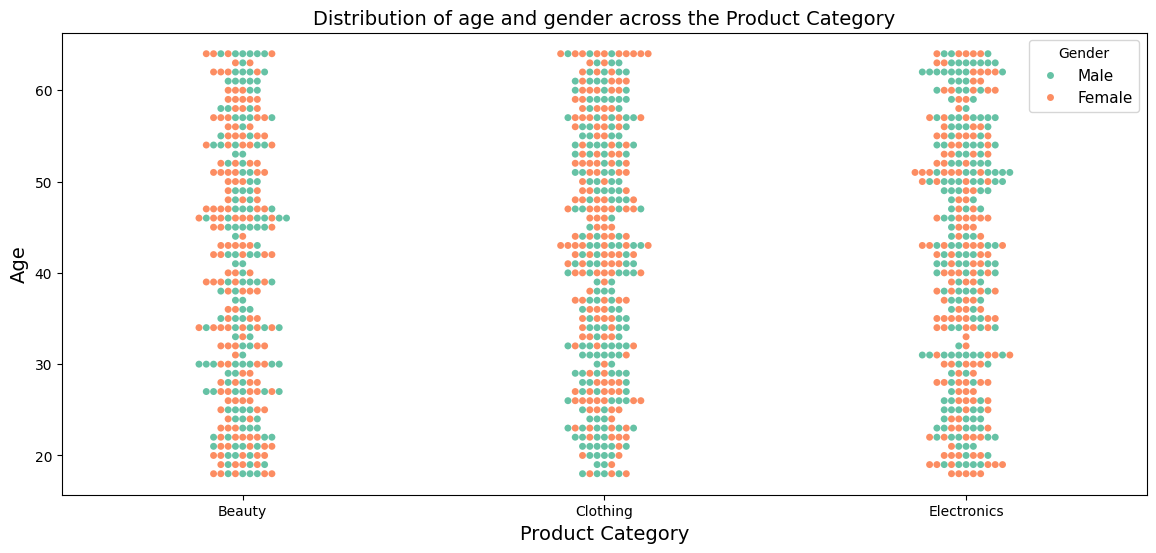

In [214]:
plt.figure(figsize=(14,6))
sns.swarmplot(x='Product Category', y='Age', hue='Gender', data=df, palette='Set2')
plt.title("Distribution of age and gender across the Product Category", fontsize=14)
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Age', fontsize=14)
plt.legend(title='Gender', loc='upper right', fontsize=11)
plt.show()

<Axes: title={'center': 'age of the person'}, xlabel='Age', ylabel='count'>

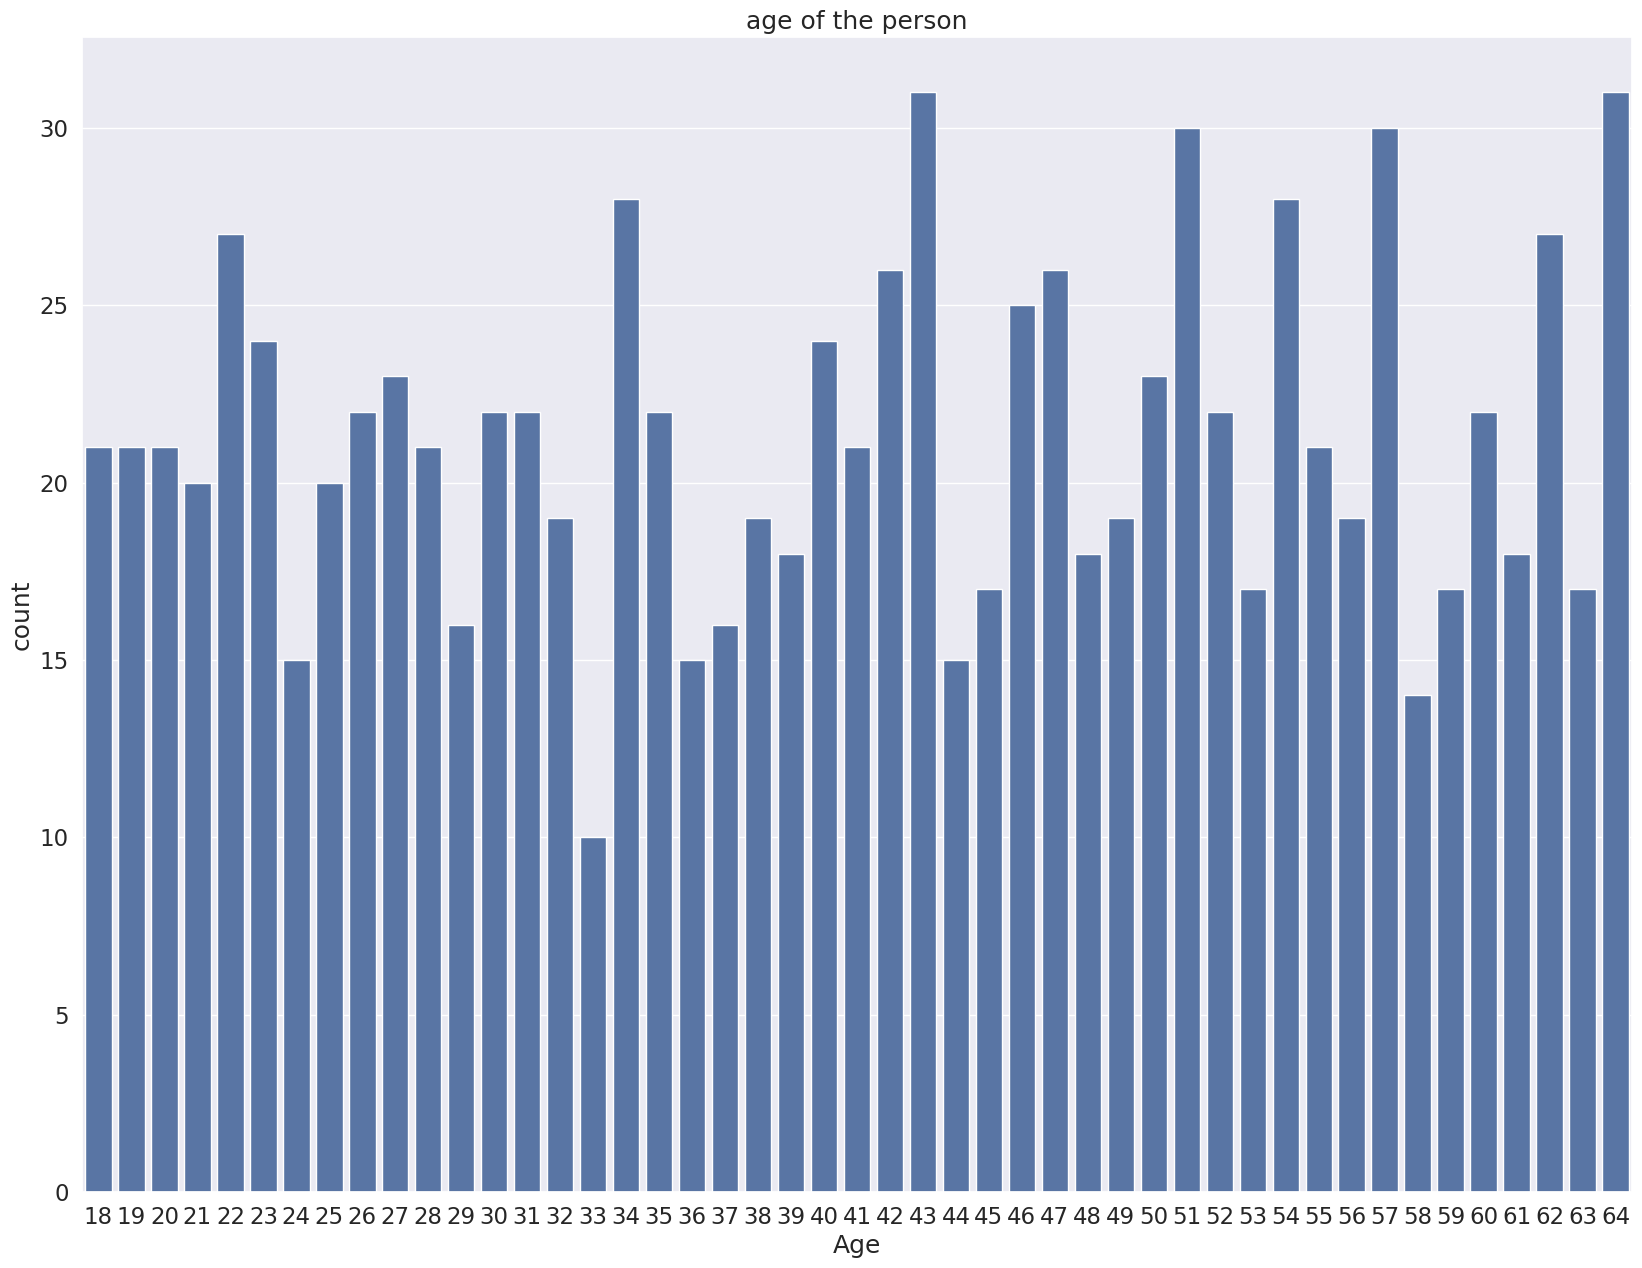

In [220]:
plt.figure(figsize=(20,15))
plt.title('age of the person')
plt.xlabel('Age')
sns.countplot(x='Age', data=df)

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   int32         
 10  Age groups        1000 non-null   category      
dtypes: category(1), datetime64[ns](1), int32(1), int64(5), object(3)
memory usage: 75.5+ KB


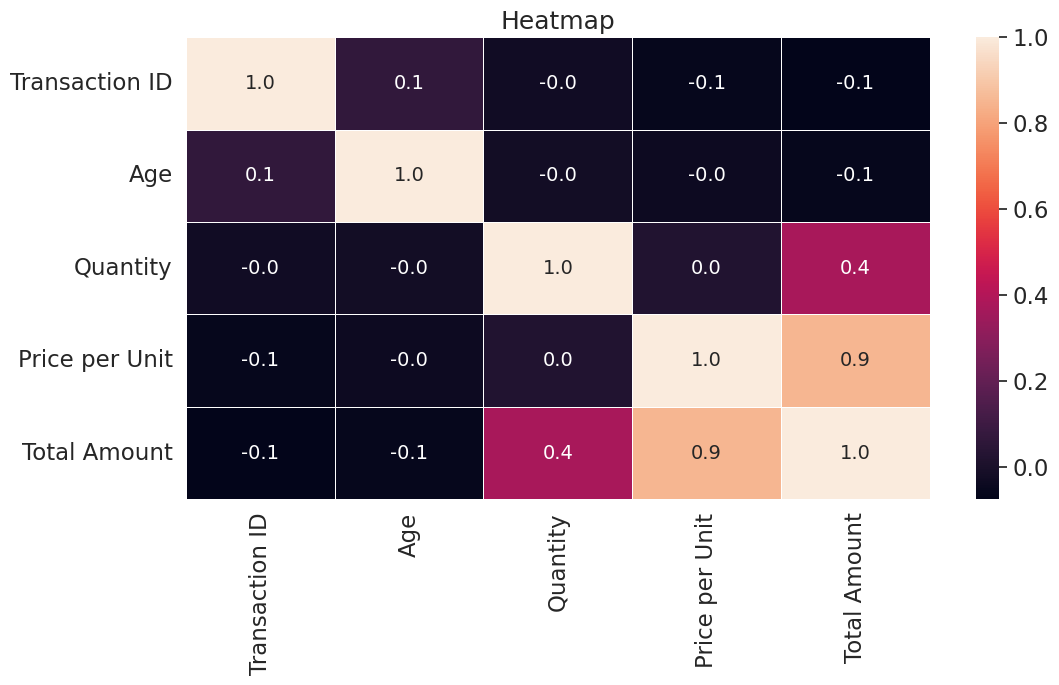

In [219]:
correlation = df[df.dtypes[df.dtypes == 'int64'].index].corr()

sns.set(font_scale=1.5)

plt.figure(figsize=(12, 6))
plt.title("Heatmap", fontsize=18)

ax = sns.heatmap(
    correlation,
    annot=True,
    annot_kws={"size": 14},
    fmt=".1f",
    linewidths=.5
)